# ERA LTE × climate-toolkit — Colab walkthrough

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/CGIAR-Climate-Data-Hub/climate-toolkit/blob/main/examples/era_lte_colab.ipynb)

Validate the toolkit's climate metrics against ERA's long-term-experiment (LTE) field records, then explore how yield relates to climate — with plots.

Credential-free by default (NASA POWER + the public ERA `lte_final.csv`). The section-3 trend example is set to the Earth Engine source `era_5` — do section 2 first, or switch its `--source` to `nasa_power` to run it credential-free. Then run the cells top to bottom.

In [1]:
# Self-heal a stale working directory: a %cd from an earlier run can leave the
# kernel in a folder that no longer exists, which breaks relative paths such as
# the data cache (outputs/cache/...). If that happened, drop back to home.
import os
try:
    os.getcwd()
except OSError:
    os.chdir(os.path.expanduser("~"))

%pip install -q climate-toolkit

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.7/58.7 kB 863.0 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.9/386.9 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.1/196.1 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.8/80.8 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 307.5/307.5 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.2/58.2 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 3.5 MB/s eta 0:00:00


## 1. Install

Install the `climate-toolkit` package from PyPI (a few seconds on Colab). The ERA workflow scripts come from a quick repo clone in the next section.

In [2]:
import climate_toolkit as ct

print(f"climate_toolkit v{ct.__version__}")
print("Public API:", [n for n in ct.__all__ if not n.startswith("__")])

climate_toolkit v0.1.0
Public API: ['analyze_climate_statistics', 'compare_climate_periods', 'compare_climate_sources', 'compare_station_to_grids', 'download_station_data', 'evaluate_hazards', 'fetch_climate_data', 'run_pipeline']


## 2. Set up Google Earth Engine access (foundational)

Most gridded and projection sources (`agera_5`, `era_5`, `chirps_*`, `imerg`, `terraclimate`, `cmip_6`, `nex_gddp`, ...) route through **Google Earth Engine**. This is the one piece of setup the toolkit needs — do it once and it works everywhere (Colab, your laptop, servers). It is **free for noncommercial use** (research, academia, nonprofit) and needs no credit card:

1. Go to https://code.earthengine.google.com/register with your Google account.
2. Choose **"Register a Noncommercial or Commercial Cloud project"**, then **create a new Google Cloud project** (or reuse one).
3. Usage type: **Unpaid usage** (do *not* pick "Paid usage"). Category: e.g. **Academia & Research** or **Nonprofit**.
4. Note the **project id** you registered (looks like `my-project-123456`), paste it below, set `RUN_EARTH_ENGINE = True`, and run the cell. Colab pops up a Google sign-in.

Full walkthrough with screenshots: [Getting started → Google Earth Engine credentials](https://CGIAR-Climate-Data-Hub.github.io/climate-toolkit/getting_started/#2-google-earth-engine-credentials).

> **No account yet?** Leave `RUN_EARTH_ENGINE = False` and keep going — the walkthrough runs credential-free on NASA POWER. The section-3 trend example is set to `era_5` (Earth Engine); switch its `--source` to `nasa_power` to run it without this setup.

In [3]:
RUN_EARTH_ENGINE = True  # set True once you have registered (free for noncommercial use)
GCP_PROJECT_ID = "rugged-habitat-486314-m3"  # <-- your registered Cloud project id

# Tip: instead of pasting the id here, store it once in Colab's Secrets
# (key icon in the left sidebar, name it GCP_PROJECT_ID) and use:
#   from google.colab import userdata
#   GCP_PROJECT_ID = userdata.get("GCP_PROJECT_ID")

if RUN_EARTH_ENGINE:
    import os

    import ee

    ee.Authenticate()  # interactive Google sign-in (works natively in Colab)
    os.environ["GCP_PROJECT_ID"] = GCP_PROJECT_ID
    ee.Initialize(project=GCP_PROJECT_ID)
    print("Earth Engine ready — all sources available.")
else:
    print("Earth Engine disabled — the walkthrough still runs on NASA POWER; switch the section-3 example's --source to nasa_power.")

Earth Engine ready — all sources available.


## 3. Fetch daily climate data → pandas DataFrame

`nasa_power` uses plain HTTPS — no Earth Engine involved. We fetch one year of daily rainfall and temperature for Nairobi, Kenya. Swap in your own coordinates.

In [4]:
from datetime import date

from climate_toolkit.fetch_data.source_data.sources.utils.models import ClimateVariable

LAT, LON = -1.286, 36.817  # Nairobi, Kenya — swap in your own site

VARS = [
    ClimateVariable.precipitation,
    ClimateVariable.max_temperature,
    ClimateVariable.min_temperature,
]

df = ct.fetch_climate_data(
    source="nasa_power",
    location_coord=(LAT, LON),
    variables=VARS,
    date_from=date(2020, 1, 1),
    date_to=date(2020, 12, 31),
    verbose=False,
)
df.head()

,date,precipitation,max_temperature,min_temperature
0,2020-01-01,0.04,27.17,14.07
1,2020-01-02,1.01,25.65,15.73
2,2020-01-03,0.67,25.96,15.82
3,2020-01-04,0.12,24.90,15.46
4,2020-01-05,0.38,25.30,14.87


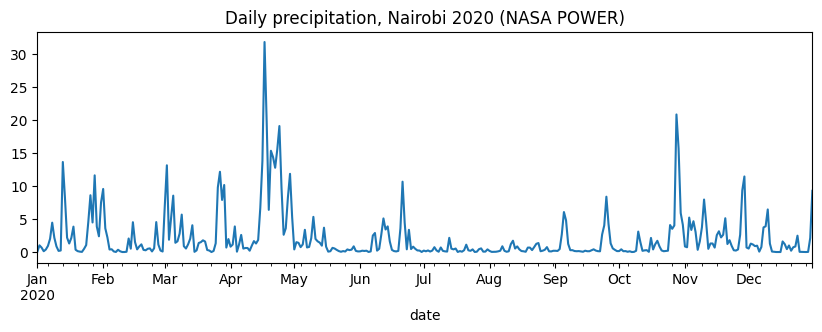

In [5]:
# It's a normal DataFrame — plot, resample, export as usual.
df.set_index("date")["precipitation"].plot(
    figsize=(10, 3), title="Daily precipitation, Nairobi 2020 (NASA POWER)"
);

# ERA LTE workflow — climate vs yield, with visualizations

The ERA workflow scripts live in the repo's `examples/` folder (they ship with the
repo, **not** the pip wheel), so we clone the repo and run from it. The public
`lte_final.csv` is **auto-downloaded** by the scripts on first use.

In [6]:
# Get the repo's `examples/` scripts. Works in Colab (clones the repo) and when
# run from the repo in VS Code / Jupyter (skips the clone — no nested copy).
# NB: keep comments off the %cd lines — a line magic eats the rest of the line.
import os
import sys
import subprocess

if os.path.exists("examples/era_lte_workflow.py"):
    pass
elif os.path.exists("era_lte_workflow.py"):
    # opened from examples/ -> step up to the repo root
    %cd ..
else:
    # fresh environment (e.g. Colab): clone the repo and enter it
    !git clone -q https://github.com/CGIAR-Climate-Data-Hub/climate-toolkit.git
    %cd climate-toolkit

from IPython.display import Image        # for showing the plots inline
def run(*args):
    """Run a repo script with the kernel's Python, quietly.
    Shows the script's output only if it fails, so normal runs stay clean."""
    r = subprocess.run([sys.executable, *args], capture_output=True, text=True)
    if r.returncode != 0:
        print(r.stdout)
        print(r.stderr)
        raise SystemExit("failed: " + " ".join(args))

/content/climate-toolkit


### Peek at `lte_final.csv`

A quick glance at the public ERA long-term-experiment table these workflows use. `era_fetch_data.py` downloads it once. Note the `Variety` (cultivar) column — it is often swapped over an LTE's life, so the section-3 trend plots mark where it changes.

In [7]:
import pandas as pd
run('examples/era_fetch_data.py')
lte = pd.read_csv("lte_final.csv", low_memory=False)

# The crop and the cultivar/variety grown. Variety is often swapped over an LTE's
# life, so it is carried into the yield tables and marked on the section-3 plots.
lte[["Site.ID", "Product.Simple", "Variety"]].dropna(subset=["Variety"]).head()

,Site.ID,Product.Simple,Variety
37,"ICIPE, Mbita Point",maize,WH505
38,"ICIPE, Mbita Point",maize,WH505
39,"ICIPE, Mbita Point",maize,WH505
40,"ICIPE, Mbita Point",maize,WH505
41,"ICIPE, Mbita Point",maize,WH505


## 1. List the ERA sites

In [8]:
!{sys.executable} examples/era_lte_workflow.py examples/data/unique_sites_for_toolkit.csv --list-sites

Awassa
Chebunyo
Weruga
Kand. Kareti
Chepkumia
Sosiot
Otamba
Githunguri
Vih. Maragoli
Upepo
Ol Ngarua
Rotian
Eld. Ravine
Baraton
Kapenguria
Bugar
Kiamokama
Ol Joro Orok
Mau Summit
Njambini
Tongaren
Turbo
Kamakoiwa
Kaguru ATC
Kerugoya
Kavutiri
Moi TTC
Tulaga
AREX Training Centre farm, Domboshava
Cinzana ARS_loamy
Cinzana ARS_clay
Ngoungoumou
Evendissi
May Zegzeg
Alemaya University Hirna Station
Samaru
ICIPE Campus, Mbita Point
ICRISAT, Sadore
IITA Conotou
IITA, Ibadan
IITA, Mbalmayo
IITA, Onne
IITA, Sendusu NaCRRI, Namulonge
INERA, Saria
Irrigation Research Station, Kadawa
Kagasa
western Kenya 5
western Kenya 20
western Kenya35
western Kenya 80
western Kenya 105
Mtwapa Agroforestry Energy Center
KARI, Katumani (ICRAF Machakos)
Makoka ARS, Zomba
Msekera RS 91-3
Msekera RS 92-3
Nazombe
Mashitsi Research Station
Misamfu ARS
Murewa-HF_CLAY
Murewa-OF_CLAY
Murewa-HF_SANDY
Murewa-OF_SANDY
NARL, Kabete
Ngwazi, Mufindi
Nioro
Nkhande
Nyabeda
South-western
University of Ibadan Research Farm
Ibadan


## 2. Run the workflow — single site
(Use `--limit N` or `--site` to keep it fast; running *all* sites takes several minutes.)

In [9]:
run('examples/era_lte_workflow.py', 'examples/data/unique_sites_for_toolkit.csv', '--site', 'Awassa', '--out', 'single.csv')
import pandas as pd
pd.read_csv("single.csv").head()

,site_id,lat,lon,start_year,end_year,mode,fixed_season,year,season_number,tk_rain_total_mm,tk_rainy_days,tk_dry_days,tk_NDWS,tk_WRSI
0,Awassa,7.1,38.5,1996,2000,fixed,"02-01:05-31,06-01:09-30",1996,1,732.4,89,32,43,65.76
1,Awassa,7.1,38.5,1996,2000,fixed,"02-01:05-31,06-01:09-30",1996,2,1161.6,115,7,0,100.00
2,Awassa,7.1,38.5,1996,2000,fixed,"02-01:05-31,06-01:09-30",1997,1,570.0,65,55,47,54.75
3,Awassa,7.1,38.5,1996,2000,fixed,"02-01:05-31,06-01:09-30",1997,2,605.6,109,13,25,74.05
4,Awassa,7.1,38.5,1996,2000,fixed,"02-01:05-31,06-01:09-30",1998,1,586.4,75,45,42,61.45


### Multiple sites

In [10]:
run('examples/era_lte_workflow.py', 'examples/data/unique_sites_for_toolkit.csv', '--site', 'Awassa', '--site', 'Samaru', '--out', 'multi.csv')
pd.read_csv("multi.csv").head()

,site_id,lat,lon,start_year,end_year,mode,fixed_season,year,season_number,tk_rain_total_mm,tk_rainy_days,tk_dry_days,tk_NDWS,tk_WRSI
0,Awassa,7.1,38.5,1996,2000,fixed,"02-01:05-31,06-01:09-30",1996,1,732.4,89,32,43,65.76
1,Awassa,7.1,38.5,1996,2000,fixed,"02-01:05-31,06-01:09-30",1996,2,1161.6,115,7,0,100.00
2,Awassa,7.1,38.5,1996,2000,fixed,"02-01:05-31,06-01:09-30",1997,1,570.0,65,55,47,54.75
3,Awassa,7.1,38.5,1996,2000,fixed,"02-01:05-31,06-01:09-30",1997,2,605.6,109,13,25,74.05
4,Awassa,7.1,38.5,1996,2000,fixed,"02-01:05-31,06-01:09-30",1998,1,586.4,75,45,42,61.45


### Which sites can I use for the trends?

Sections 3–4 draw on `lte_final.csv` — a *different, larger* set of sites (any with reported crop yield) than the ~100 shown by section 1's `--list-sites`. So look here, not in section 1, for the trend sites. The cell below prints them (and the exact count); pass any name to `--site` in the cells that follow.

**How `--site` matches:** case-insensitive **substring** — `--site "Makoka"` finds "Makoka ARS", so you don't need the full name. Keep it distinctive, though: a generic string like `"ARC"` matches several sites at once. When unsure, copy a name from the list below.

In [11]:
import pandas as pd
from examples.era_fetch_data import maybe_fetch

_lf = pd.read_csv(maybe_fetch("lte_final.csv"), low_memory=False)
yield_sites = sorted(_lf.loc[_lf["Out.SubInd"] == "Crop Yield", "Site.ID"].dropna().astype(str).unique())
print(f"{len(yield_sites)} sites available for the yield trends — pass any (or a distinctive part) to --site:")
for s in yield_sites:
    print("  ", s)

257 sites available for the yield trends — pass any (or a distinctive part) to --site:
   ARC Small Grain, Bethlehem
   ARC, Nietvoorbij
   AREX Training Centre farm, Domboshava
   Africa Rice, Fanaye
   Africa Rice, Ndiaye
   Agricultural Research Station, University of Agricultural Sciences, GKVK campus, Bengaluru, Karnataka.
   Ahmadu Bello University, Zaria
   Akola
   Alemaya University Hirna Station
   Alemaya University Hirna Station - Ust
   Alemaya University Hirna Station -Pel
   Alemaya University Hirna Station B
   All Indian Coordinated Research Project on Dryland Agriculture- Arjia
   Aludeka Site
   Awassa
   Bako Agricultural Research Center
   Balaka..Ntcheu..Salima
   Banaras Hindu University farm (BHU), Varanasi
   Banaras Hindu University, Varanasi
   Bangabandhu Sheikh Mujibur Rahman Agricultural University
   Bangladesh Agricultural Research Institute (BARI)
   Bangladesh Rice Research Institute
   Bangladesh Rice Research Institute, (BRRI) Gazipur
   Baraton
   B

## 3. Yield vs toolkit climate — trend figures
Toolkit variable as bars, one yield line per treatment, per site. We recommend trying various datasets, as some over- or underestimate rainfall. This will help identify which dataset correlates most with yields. Try `--source chirps_v2`, `chirps_v3_daily_rnl`, `agera_5`, or `era_5` instead of the default `nasa_power`. The cell below uses `era_5` (Earth Engine), so complete section 2 first — or change `--source` to `nasa_power` to run it credential-free. Dashed vertical guides mark the crop **variety**: one at the first year (the variety the site started with) and one at each later switch. Sites with no recorded variety in the data — like the default **Gourton Farm** — show none; variety-rich sites such as Nyabeda or Kouve show several.

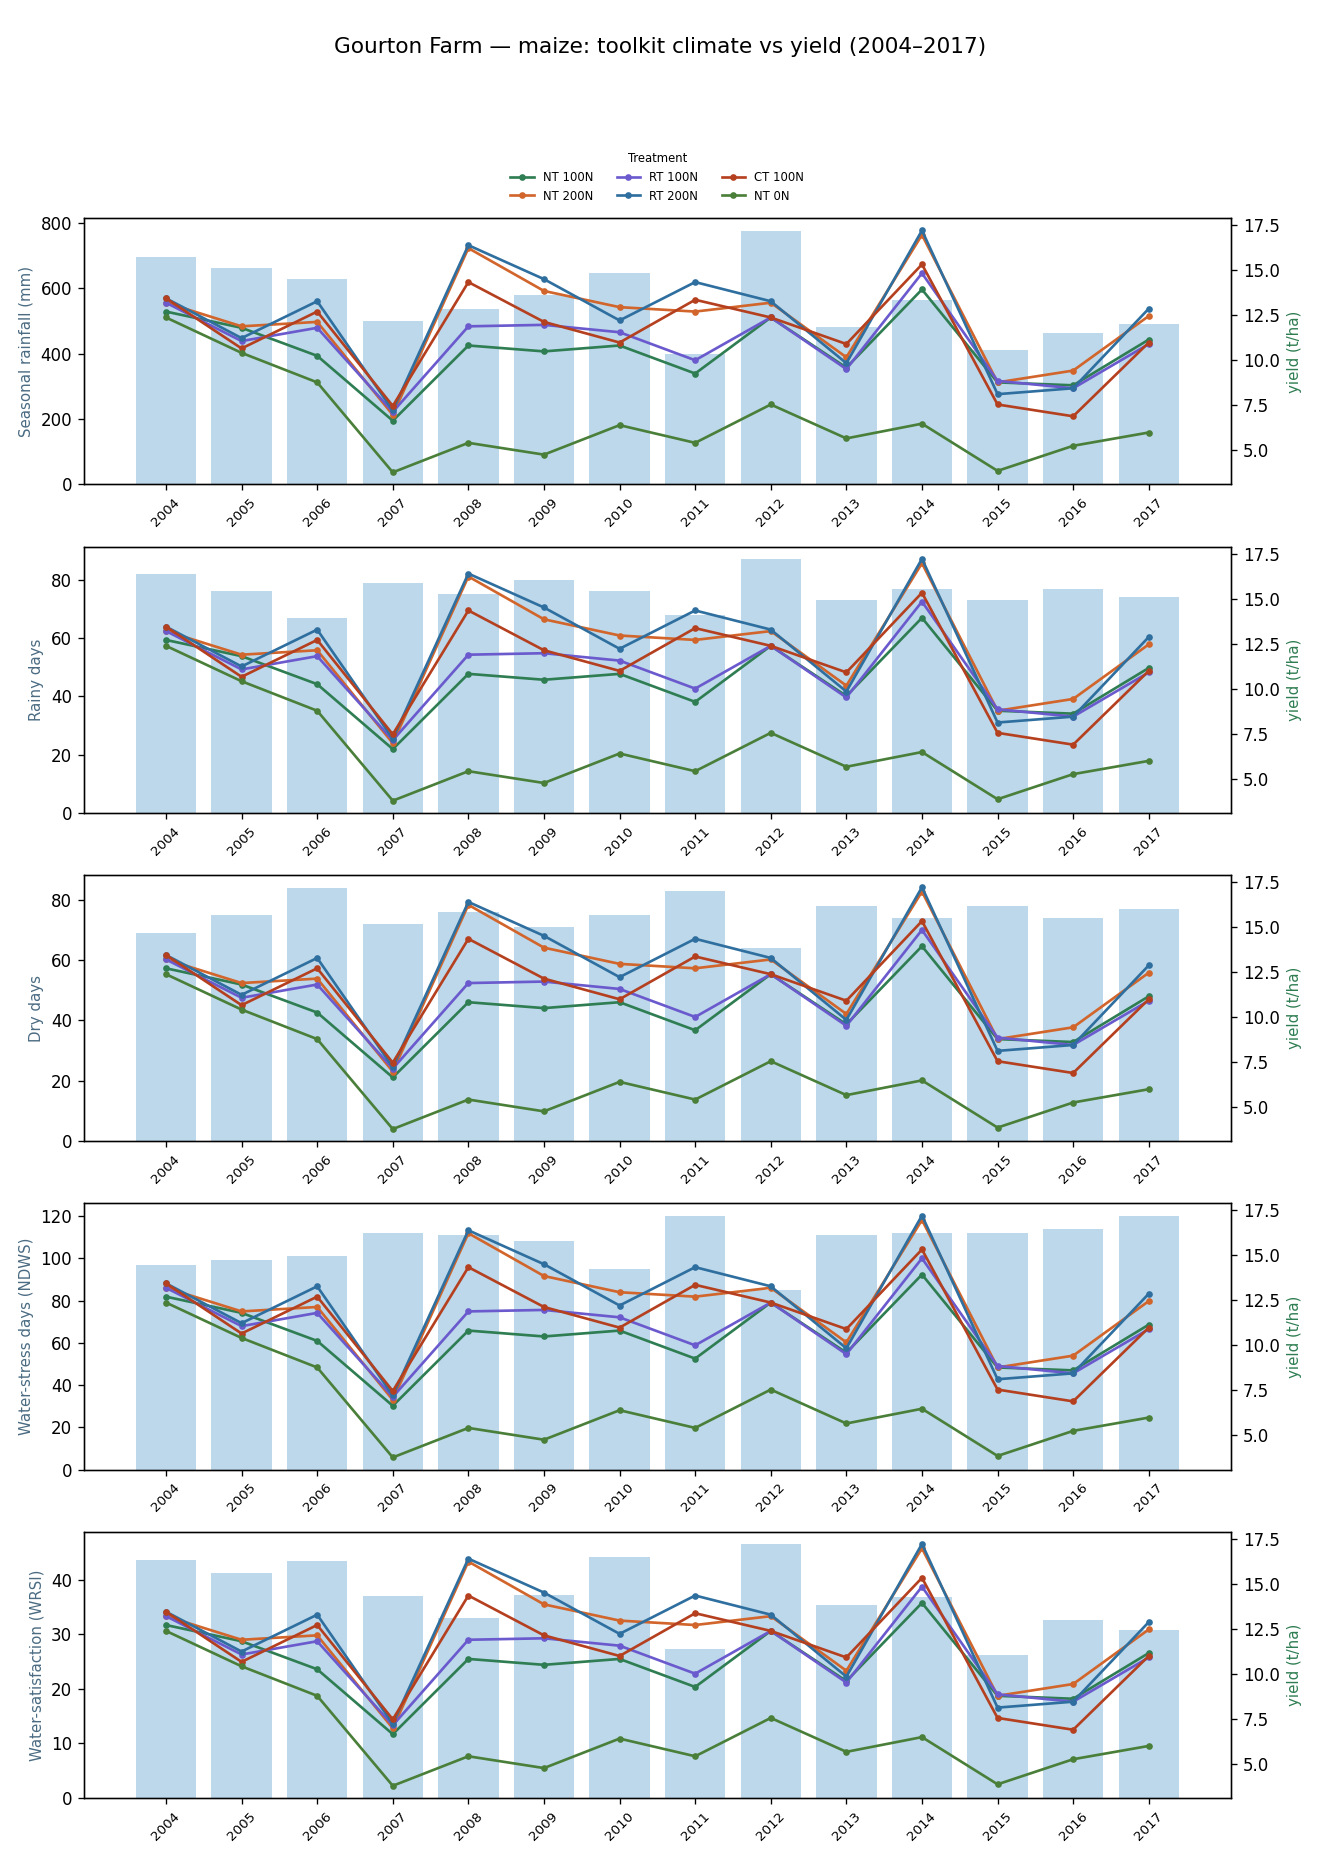

In [12]:
run('examples/era_yield_analysis.py', 'lte_final.csv', '--source', 'era_5', '--site', 'Gourton', '--out', 'era_gourton.csv')
run('examples/era_yield_plot.py', 'era_gourton.csv', '--site', 'Gourton', '--out', 'era_gourton_trends.png')
Image("era_gourton_trends.png")

In [14]:
pd.read_csv("era_gourton.csv").head()

,lte_id,code,site_key,index,site_id,year,crop,variety,treatment,yield_t_ha,tk_rain_total_mm,tk_rainy_days,tk_dry_days,tk_NDWS,tk_WRSI
0,LTE0175,AC0098,-28.9241 29.5607 B100,139643,Gourton Farm,2004,maize,NaN,NT 100N,12.705,694.8,82,69,97,43.59
1,LTE0175,AC0098,-28.9241 29.5607 B100,139644,Gourton Farm,2004,maize,NaN,NT 200N,13.197,694.8,82,69,97,43.59
2,LTE0175,AC0098,-28.9241 29.5607 B100,139645,Gourton Farm,2004,maize,NaN,NT 0N,12.377,694.8,82,69,97,43.59
3,LTE0175,AC0098,-28.9241 29.5607 B100,139646,Gourton Farm,2004,maize,NaN,NT 100N,12.705,694.8,82,69,97,43.59
4,LTE0175,AC0098,-28.9241 29.5607 B100,139647,Gourton Farm,2004,maize,NaN,NT 200N,13.197,694.8,82,69,97,43.59


### Match a specific practice subset (e.g. the NT nitrogen rates)

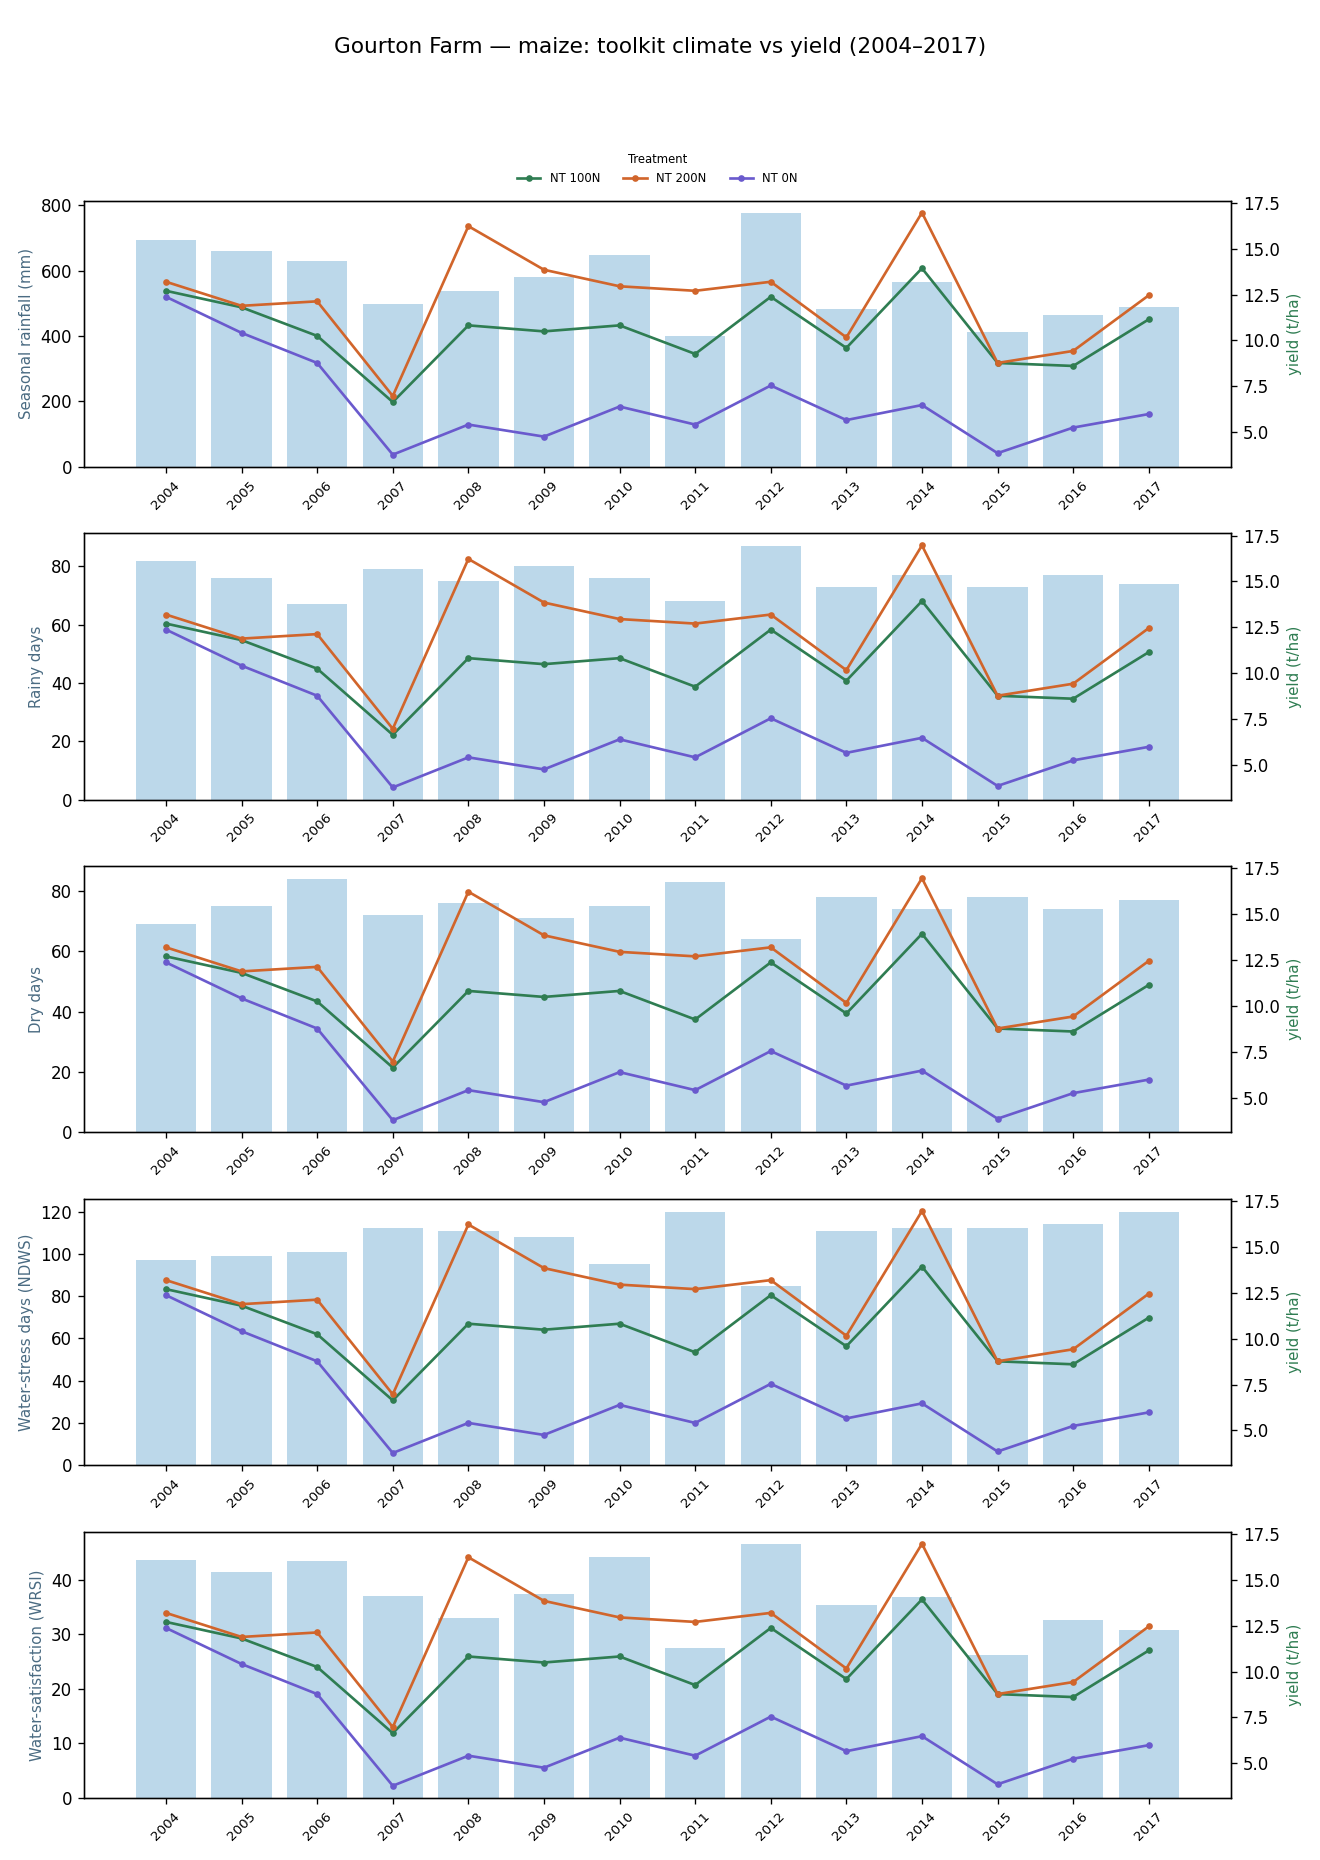

In [15]:
run('examples/era_yield_plot.py', 'era_gourton.csv', '--site', 'Gourton', '--treatments', 'NT 0N,NT 100N,NT 200N', '--out', 'gourton_NT.png')
Image("gourton_NT.png")

##Adaptation Benefit (AB)
A minimal Python function that implements the Adaptation Benefit (AB) formula from the CGIAR indicator framework,

In [79]:
def calculate_adaptation_benefit(A, P_stress, g_stress, g_norm, g_risk, Pr, s):
    """
    Calculate Adaptation Benefit (AB) based on CGIAR v3.0 framework.

    Parameters:
    A (float): Adoption (e.g., hectares, households, service users)
    P_stress (float): Probability of stress (0–1)
    g_stress (float): Gain per unit in stress season
    g_norm (float): Gain per unit in normal season
    g_risk (float): Risk-enabled gain (behavioral change effect)
    Pr (float): Price conversion factor ($ per unit)
    s (float): CGIAR contribution share (0–1)

    Returns:
    float: Adaptation Benefit (AB) in US dollars per year
    """
    avoided_loss = P_stress * (g_stress - g_norm)
    enabled_gain = g_risk
    AF = avoided_loss + enabled_gain
    AB = A * AF * Pr * s
    return AB


Below is a hazard classification function. This will let you automatically label each ERA LTE season as stress or normal based on rainfall thresholds, and then compute `P_stress`, `g_stress`, and `g_norm`.

In [80]:
import pandas as pd

def classify_seasons_era(df, rainfall_col="tk_rain_total_mm",
                         yield_col="yield_t_ha",
                         threshold=400):
    """
    Classify ERA LTE seasons as stress or normal based on rainfall threshold,
    and compute P_stress, g_stress, g_norm.

    Parameters:
    df (pd.DataFrame): ERA LTE dataframe with rainfall, yield, year, treatment, variety, site_id
    rainfall_col (str): Column name for seasonal rainfall (mm)
    yield_col (str): Column name for yield (t/ha)
    threshold (float): Rainfall threshold (mm) below which season is stress

    Returns:
    dict: {
        'P_stress': Probability of stress (fraction of seasons),
        'g_stress': Mean yield in stress seasons,
        'g_norm': Mean yield in normal seasons,
        'classified_df': Original df with added 'season_type' column
    }
    """
    # Classify seasons
    df['season_type'] = df[rainfall_col].apply(
        lambda x: 'stress' if x < threshold else 'normal'
    )

    # Compute probabilities and gains
    stress_seasons = df[df['season_type'] == 'stress']
    normal_seasons = df[df['season_type'] == 'normal']

    P_stress = len(stress_seasons) / len(df) if len(df) > 0 else 0
    g_stress = stress_seasons[yield_col].mean() if not stress_seasons.empty else 0
    g_norm = normal_seasons[yield_col].mean() if not normal_seasons.empty else 0

    return {
        'P_stress': P_stress,
        'g_stress': g_stress,
        'g_norm': g_norm,
        'classified_df': df
    }


Python Code: Grouped AB Calculation

We can **quantify resilience differences per treatment or variety**, not just visualize them. We’ll compute **Adaptation Benefit (AB)** separately for each group.


## ✨ What You’ll Get
- A **table of AB values per treatment or variety**, showing:
  - \(P_{stress}\) (fraction of stress seasons)  
  - \(g_{stress}\) (mean yield in stress seasons)  
  - \(g_{norm}\) (mean yield in normal seasons)  
  - **AB in USD/year**  

This lets you **quantify resilience differences**:  
- Treatments or varieties with **positive AB** are climate-resilient.  
- Those with **negative AB** are vulnerable under stress.  

In [81]:
def compute_grouped_ab(df, group_col, rainfall_col="tk_rain_total_mm",
                       yield_col="yield_t_ha", threshold=400,
                       A=5000, Pr=250, s=0.7, g_risk=0):
    """
    Compute Adaptation Benefit (AB) separately per treatment or variety group.

    Parameters:
    df (pd.DataFrame): ERA LTE dataframe
    group_col (str): Column to group by ("treatment" or "variety")
    rainfall_col (str): Column name for rainfall (mm)
    yield_col (str): Column name for yield (t/ha)
    threshold (float): Rainfall threshold (mm) for stress classification
    A (float): Adoption (hectares, households, service users)
    Pr (float): Price conversion factor ($ per unit)
    s (float): CGIAR contribution share (0–1)
    g_risk (float): Risk-enabled gain (default 0 unless measured)

    Returns:
    pd.DataFrame: AB values per group
    """

    results = []

    # Classify seasons
    df['season_type'] = df[rainfall_col].apply(
        lambda x: 'stress' if x < threshold else 'normal'
    )

    # Group by treatment or variety
    for group, subset in df.groupby(group_col):
        stress_seasons = subset[subset['season_type'] == 'stress']
        normal_seasons = subset[subset['season_type'] == 'normal']

        P_stress = len(stress_seasons) / len(subset) if len(subset) > 0 else 0
        g_stress = stress_seasons[yield_col].mean() if not stress_seasons.empty else 0
        g_norm = normal_seasons[yield_col].mean() if not normal_seasons.empty else 0

        avoided_loss = P_stress * (g_stress - g_norm)
        enabled_gain = g_risk
        AF = avoided_loss + enabled_gain
        AB = A * AF * Pr * s

        results.append({
            group_col: group,
            "P_stress": P_stress,
            "g_stress": g_stress,
            "g_norm": g_norm,
            "AB_USD_per_year": AB
        })

    return pd.DataFrame(results)

since `dataset era_gourton.csv` already has rainfall, yield, year, treatment, variety, and site information, we can extend the AB function to work directly with those columns. This way We’ll compute Adaptation Benefit (AB) separately for each treatment based on computed `Pstress`, `gstress`, and `gnorm`.

In [82]:
import pandas as pd

# Load your ERA LTE dataset
df = pd.read_csv("era_gourton.csv")

# Compute AB per treatment
ab_treatment = compute_grouped_ab(df, group_col="treatment", threshold=400)
print("AB per treatment:\n", ab_treatment)

# Compute AB per variety
ab_variety = compute_grouped_ab(df, group_col="variety", threshold=400)
print("AB per variety:\n", ab_variety)

AB per treatment:
   treatment  P_stress  g_stress     g_norm  AB_USD_per_year
0   CT 100N  0.071429    13.361  11.210692    134394.230769
1   CT 200N  0.071429    15.082  11.450231    226985.576923
2     NT 0N  0.071429     5.410   6.664462    -78403.846154
3   NT 100N  0.071429     9.262  10.611615    -84350.961538
4   NT 200N  0.071429    12.705  12.168923     33504.807692
5     RT 0N  0.071429     6.475   7.711154    -77259.615385
6   RT 100N  0.071429    10.000  11.040308    -65019.230769
7   RT 200N  0.071429    14.344  12.156462    136721.153846
AB per variety:
 Empty DataFrame
Columns: []
Index: []


Visualization by grouping by treatment or variety will let you see which practices or crop varieties are resilient under stress. The results compare yield–rainfall relationships across groups.

In [85]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_grouped_yield_vs_rainfall(df, rainfall_col="tk_rain_total_mm",
                                   yield_col="yield_t_ha",
                                   year_col="year",
                                   group_col="treatment",
                                   threshold=400):
    """
    Plot yield vs rainfall grouped by treatment or variety,
    with stress seasons in red and normal seasons in blue.

    Parameters:
    df (pd.DataFrame): ERA LTE dataframe
    rainfall_col (str): Column name for rainfall (mm)
    yield_col (str): Column name for yield (t/ha)
    year_col (str): Column name for year
    group_col (str): Column to group by ("treatment" or "variety")
    threshold (float): Rainfall threshold (mm) for stress classification
    """

    # Classify seasons
    df['season_type'] = df[rainfall_col].apply(
        lambda x: 'stress' if x < threshold else 'normal'
    )

    # Scatter plot grouped by treatment/variety
    plt.figure(figsize=(12,8))
    sns.scatterplot(data=df, x=rainfall_col, y=yield_col,
                    hue="season_type", style=group_col,
                    palette={"stress":"red","normal":"blue"}, s=100)
    plt.axvline(threshold, color='gray', linestyle='--', label=f'Threshold = {threshold} mm')
    plt.xlabel("Seasonal Rainfall (mm)")
    plt.ylabel("Yield (t/ha)")
    plt.title(f"Yield vs Rainfall grouped by {group_col}")
    plt.legend()
    plt.show()

    # Time series plot grouped by treatment/variety
    plt.figure(figsize=(12,8))
    sns.lineplot(data=df, x=year_col, y=yield_col,
                 hue="season_type", style=group_col,
                 markers=True, dashes=False,
                 palette={"stress":"red","normal":"blue"})
    plt.xlabel("Year")
    plt.ylabel("Yield (t/ha)")
    plt.title(f"Yield Time Series grouped by {group_col}")
    plt.legend()
    plt.show()


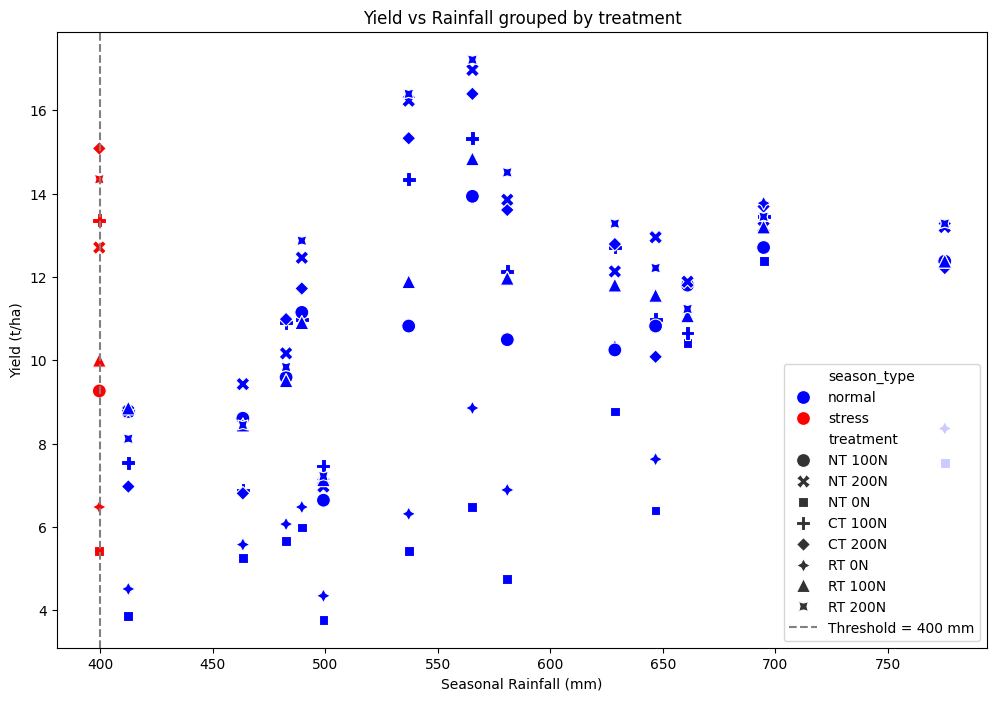

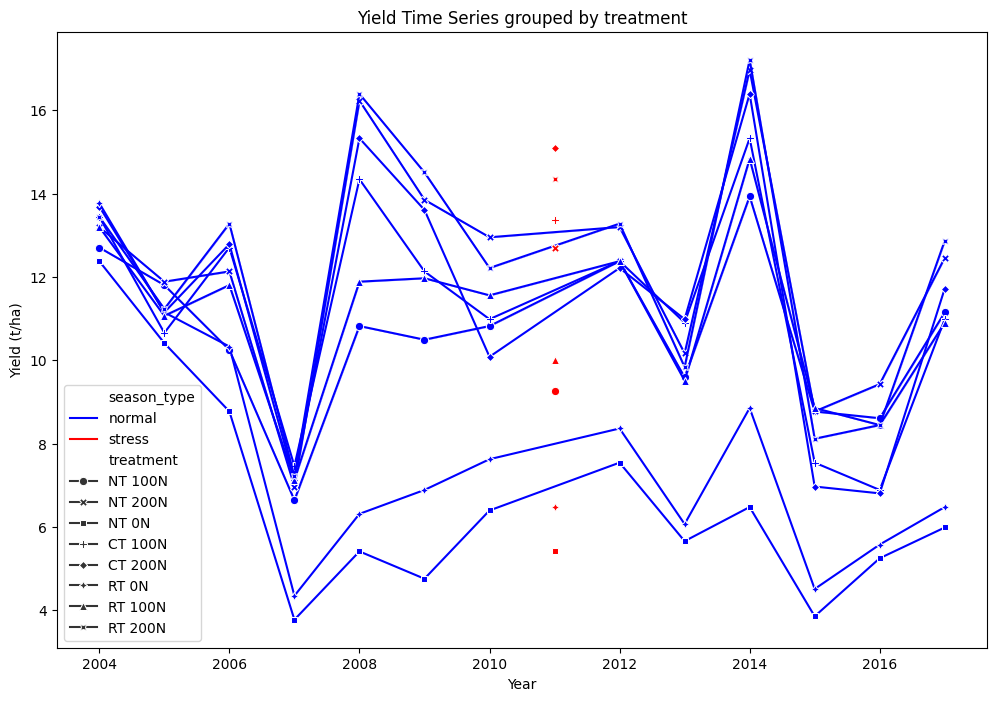

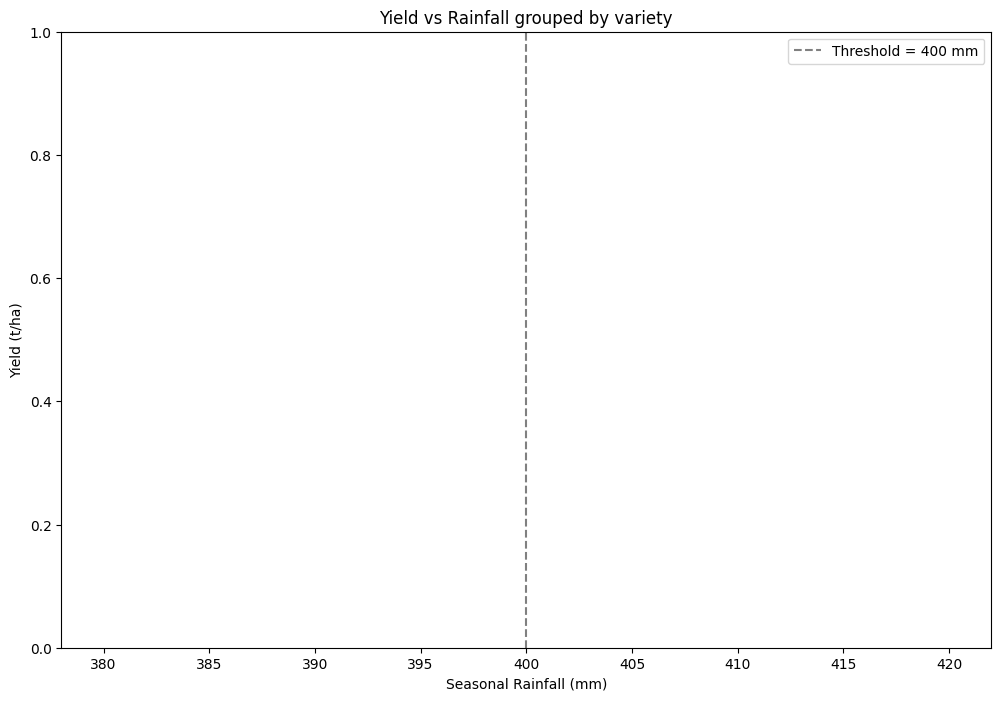

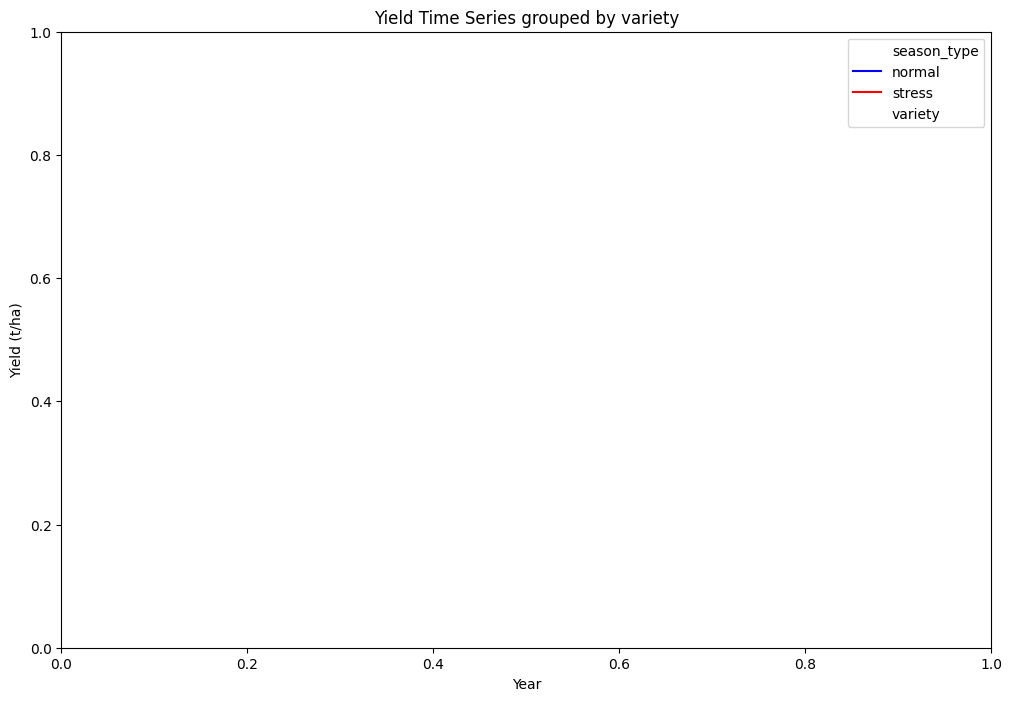

In [86]:
import pandas as pd

# Load your ERA LTE dataset
df = pd.read_csv("era_gourton.csv")

# Group by treatment
plot_grouped_yield_vs_rainfall(df, rainfall_col="tk_rain_total_mm",
                               yield_col="yield_t_ha",
                               year_col="year",
                               group_col="treatment",
                               threshold=400)

# Group by variety
plot_grouped_yield_vs_rainfall(df, rainfall_col="tk_rain_total_mm",
                               yield_col="yield_t_ha",
                               year_col="year",
                               group_col="variety",
                               threshold=400)


If you want to filter one treatment

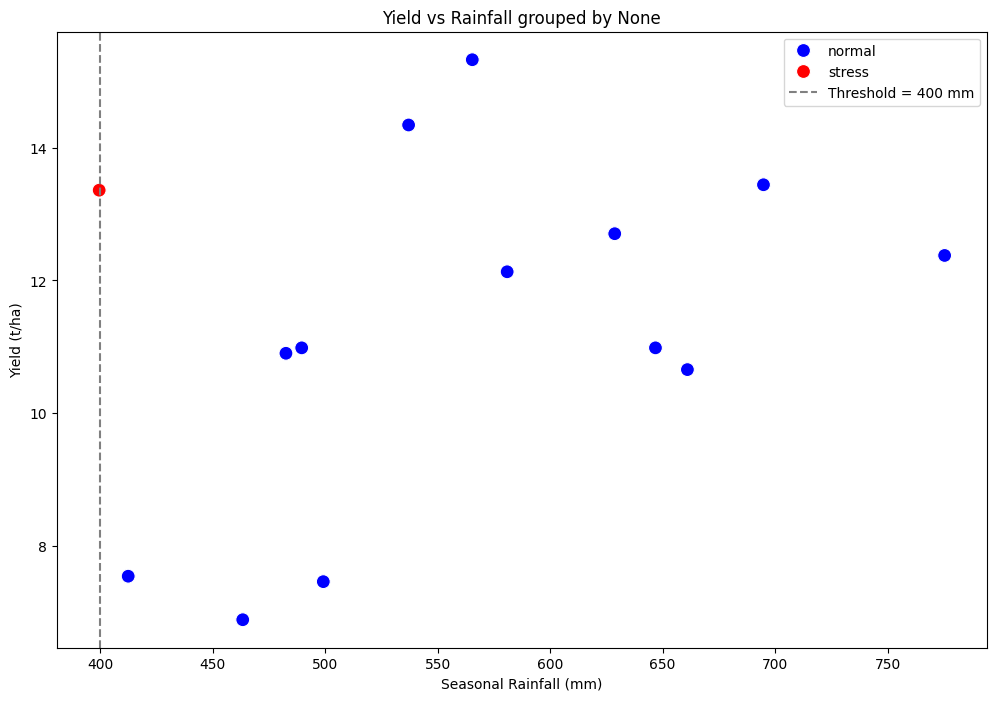

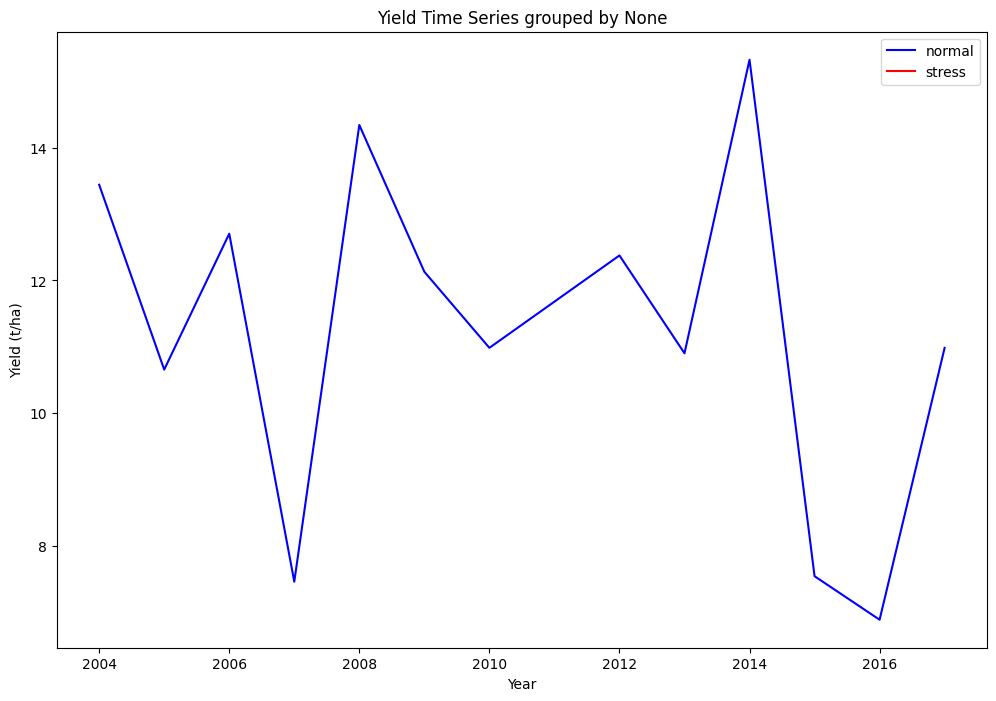

In [87]:
import pandas as pd

# Load your ERA LTE dataset
df = pd.read_csv("era_gourton.csv")

# Filter to only the "NT 100N" treatment
df_ct100n = df[df["treatment"] == "CT 100N"].copy()

# Plot yield vs rainfall for the filtered treatment
plot_grouped_yield_vs_rainfall(
    df_ct100n,
    rainfall_col="tk_rain_total_mm",
    yield_col="yield_t_ha",
    year_col="year",
    group_col=None,  # or omit this argument entirely if the function allows
    threshold=400
)

# If you still want to group by variety within this treatment:
#plot_grouped_yield_vs_rainfall(
 #   df_nt100n,
 #   rainfall_col="tk_rain_total_mm",
 #   yield_col="yield_t_ha",
  #  year_col="year",
  #  group_col="variety",
  #  threshold=400
#)

## 3b. Pick a specific crop for a multi-crop site
Some sites grew several crops (e.g. **Kouve** = cotton + maize). Use `--crop` to
choose one — otherwise you get whichever matched first.

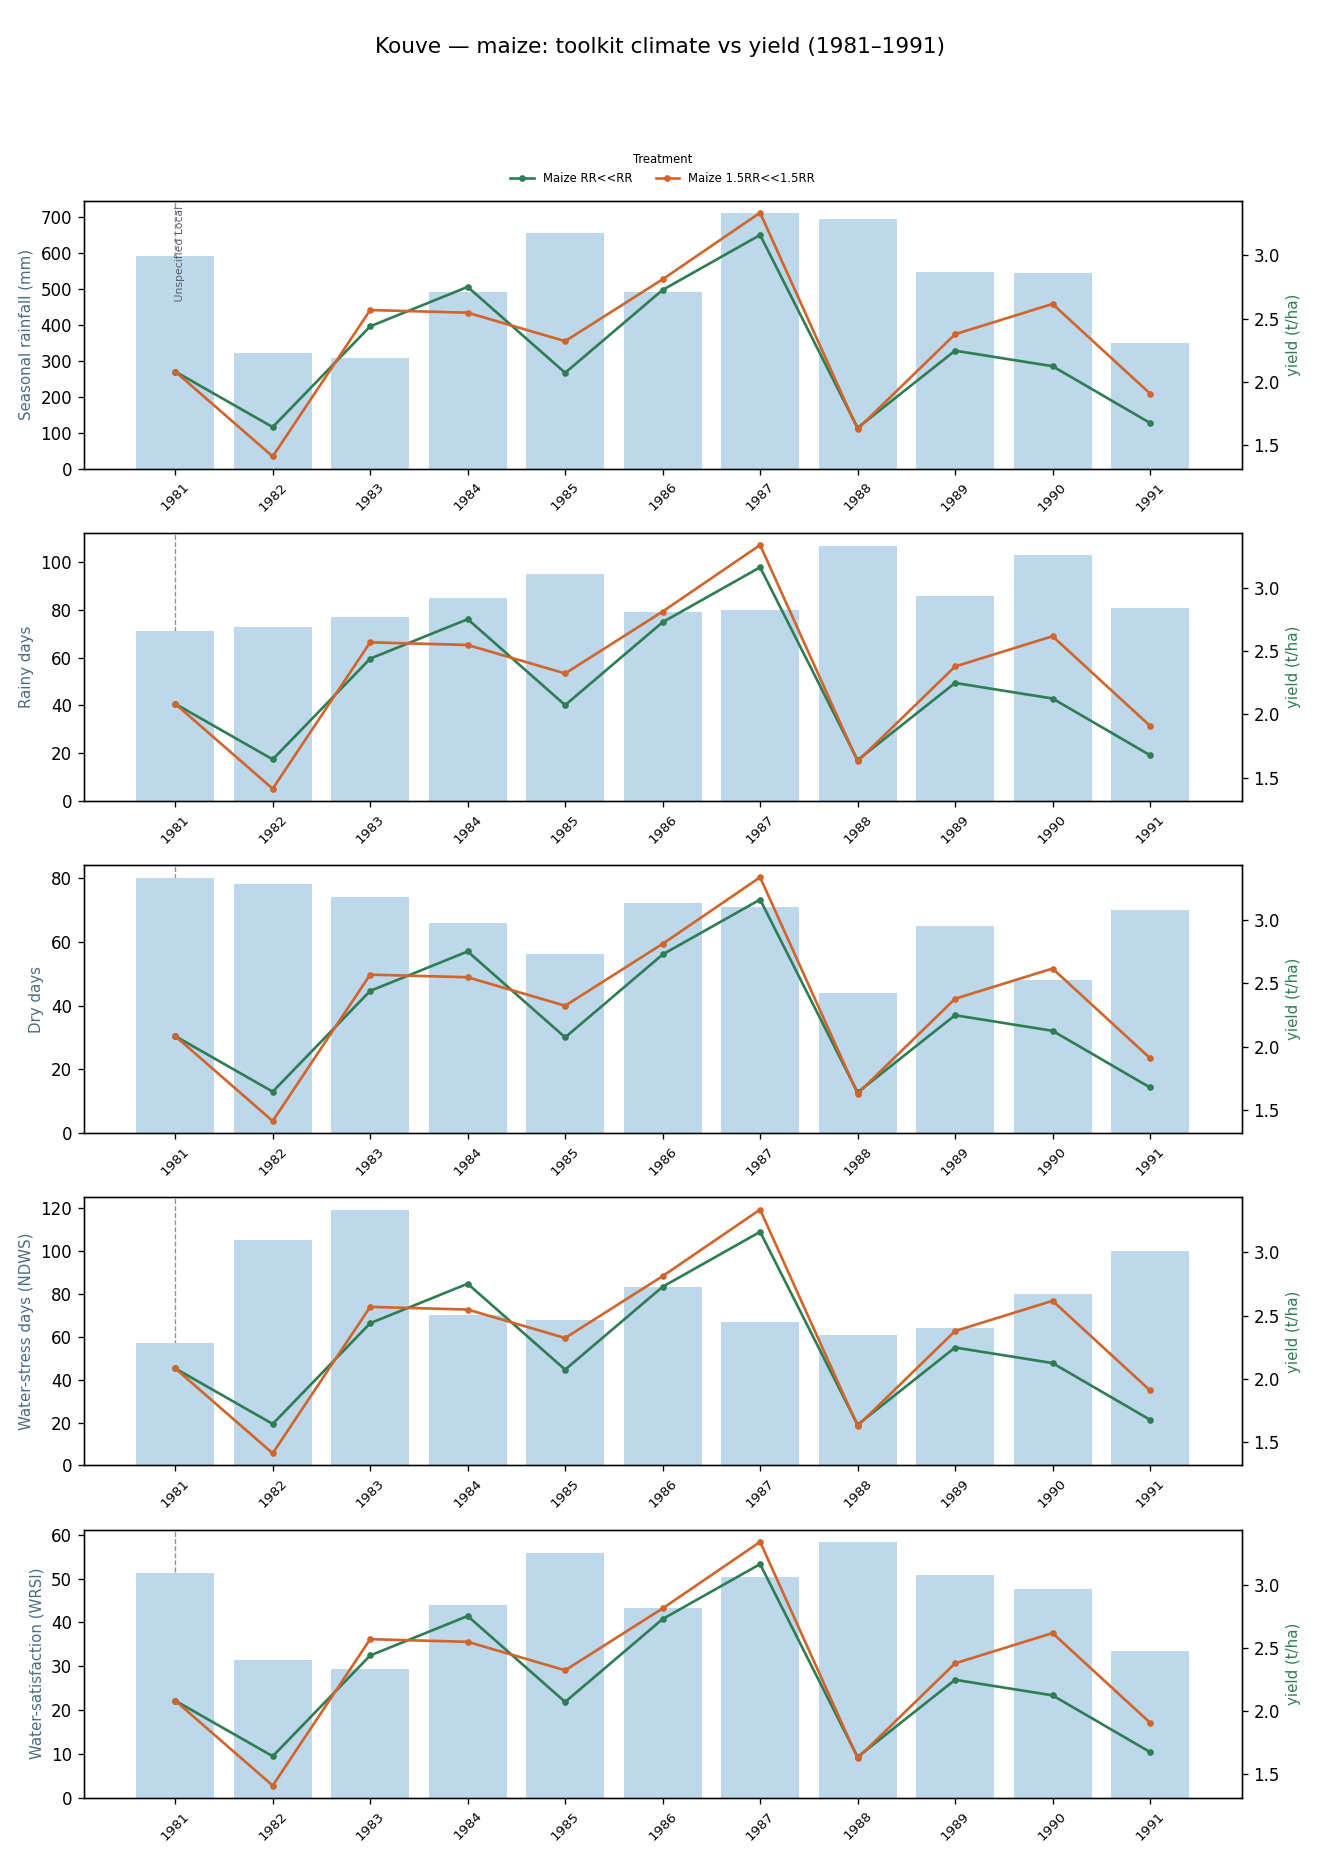

In [88]:
# Kouve, maize only (swap "Maize" for "cotton" for the other crop)
run('examples/era_yield_analysis.py', 'lte_final.csv', '--site', 'Kouve', '--crop', 'Maize', '--out', 'era_kouve_maize.csv')
run('examples/era_yield_plot.py', 'era_kouve_maize.csv', '--site', 'Kouve', '--out', 'era_kouve_maize_trends.png')
Image("era_kouve_maize_trends.png")

## 3c. Uniquely-identified records (linked to master LTE ids)
The yield table leads with `lte_id, code, site_key, index` so every site-season
record is uniquely identified and linked to the master LTE registry
(`Code` → `LTE.ID`). (`Site.Lat.Unc`/`Site.Lon.Unc` aren't in `lte_final.csv`, so
they're not shown.)

In [ ]:
import pandas as pd
cols = ["lte_id","code","site_key","index","site_id","year","crop","treatment","yield_t_ha"]
pd.read_csv("era_kouve_maize.csv")[cols].head()

## 4. Combined multi-site view
One toolkit variable vs yield across several sites. Each panel carries the same dashed **variety** markers as the single-site plots.

In [ ]:
run('examples/era_yield_analysis.py', 'lte_final.csv', '--site', 'Zimuto', '--out', 'era_Zimuto.csv')
run('examples/era_yield_analysis.py', 'lte_final.csv', '--site', 'Nyabeda', '--out', 'era_Nyabeda.csv')
run('examples/era_yield_analysis.py', 'lte_final.csv', '--site', 'Kouve', '--out', 'era_Kouve.csv')
run('examples/era_yield_multisite.py', 'era_gourton.csv', 'era_Zimuto.csv', 'era_Nyabeda.csv', 'era_Kouve.csv', '--variable', 'tk_rain_total_mm', '--out', 'era_multisite.png')
Image("era_multisite.png")

---
### Note on data coverage
NASA POWER daily data starts ~**1981**, so ERA sites whose study years are entirely
in the 1970s are skipped (you'll see a `422` message for those — harmless). For
full historical coverage you can switch `--source` to an Earth Engine source such
as `agera_5` or `chirps_v3_daily_rnl` (you set Earth Engine up at the top).